In [2]:
!pip install -q numpy pandas seaborn matplotlib scikit-learn opfython xgboost scipy


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [1]:
# Standard library
import os

# Data manipulation & visualization
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Output directories
os.makedirs('../images', exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

In [2]:
# Set default figure size and font sizes for plots
plt.rcParams.update({
    'axes.titlesize': 20,
    'axes.labelsize': 18,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'font.size': 24
})

In [3]:
df = pd.read_csv('../data/NPHA-doctor-visits.csv')
df

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
0,3,2,4,3,3,3,0,0,0,0,1,2,3,1,2
1,2,2,4,2,3,3,1,0,0,1,0,3,3,1,1
2,3,2,3,2,3,3,0,0,0,0,1,3,3,4,1
3,1,2,3,2,3,3,0,0,0,1,0,3,3,4,2
4,3,2,3,3,3,3,1,0,0,0,0,2,3,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,2,2,2,2,2,3,0,0,0,1,0,3,3,1,1
710,3,2,2,2,2,2,1,0,0,0,1,2,3,1,2
711,3,2,4,2,3,3,0,0,0,0,0,3,3,1,1
712,3,2,3,1,3,3,1,0,1,1,1,3,3,1,2


In [4]:
df.isna().sum() # Check for missing values in each column

Number of Doctors Visited                     0
Age                                           0
Phyiscal Health                               0
Mental Health                                 0
Dental Health                                 0
Employment                                    0
Stress Keeps Patient from Sleeping            0
Medication Keeps Patient from Sleeping        0
Pain Keeps Patient from Sleeping              0
Bathroom Needs Keeps Patient from Sleeping    0
Uknown Keeps Patient from Sleeping            0
Trouble Sleeping                              0
Prescription Sleep Medication                 0
Race                                          0
Gender                                        0
dtype: int64

In [5]:
df.info() # Check data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 15 columns):
 #   Column                                      Non-Null Count  Dtype
---  ------                                      --------------  -----
 0   Number of Doctors Visited                   714 non-null    int64
 1   Age                                         714 non-null    int64
 2   Phyiscal Health                             714 non-null    int64
 3   Mental Health                               714 non-null    int64
 4   Dental Health                               714 non-null    int64
 5   Employment                                  714 non-null    int64
 6   Stress Keeps Patient from Sleeping          714 non-null    int64
 7   Medication Keeps Patient from Sleeping      714 non-null    int64
 8   Pain Keeps Patient from Sleeping            714 non-null    int64
 9   Bathroom Needs Keeps Patient from Sleeping  714 non-null    int64
 10  Uknown Keeps Patient from Sleeping          714 n

In [6]:
df.describe() # Summary statistics for numerical columns

,Number of Doctors Visited,Age,Phyiscal Health,Mental Health,Dental Health,Employment,Stress Keeps Patient from Sleeping,Medication Keeps Patient from Sleeping,Pain Keeps Patient from Sleeping,Bathroom Needs Keeps Patient from Sleeping,Uknown Keeps Patient from Sleeping,Trouble Sleeping,Prescription Sleep Medication,Race,Gender
count,714.000000,714.0,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.000000,714.00000
mean,2.112045,2.0,2.794118,1.988796,3.009804,2.806723,0.247899,0.056022,0.218487,0.504202,0.417367,2.407563,2.829132,1.425770,1.55042
std,0.683441,0.0,0.900939,0.939928,1.361117,0.586582,0.432096,0.230126,0.413510,0.500333,0.493470,0.670349,0.546767,1.003896,0.49780
min,1.000000,2.0,-1.000000,-1.000000,-1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,1.000000,1.00000
25%,2.000000,2.0,2.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,3.000000,1.000000,1.00000
50%,2.000000,2.0,3.000000,2.000000,3.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,3.000000,3.000000,1.000000,2.00000
75%,3.000000,2.0,3.000000,3.000000,4.000000,3.000000,0.000000,0.000000,0.000000,1.000000,1.000000,3.000000,3.000000,1.000000,2.00000
max,3.000000,2.0,5.000000,5.000000,6.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,3.000000,5.000000,2.00000


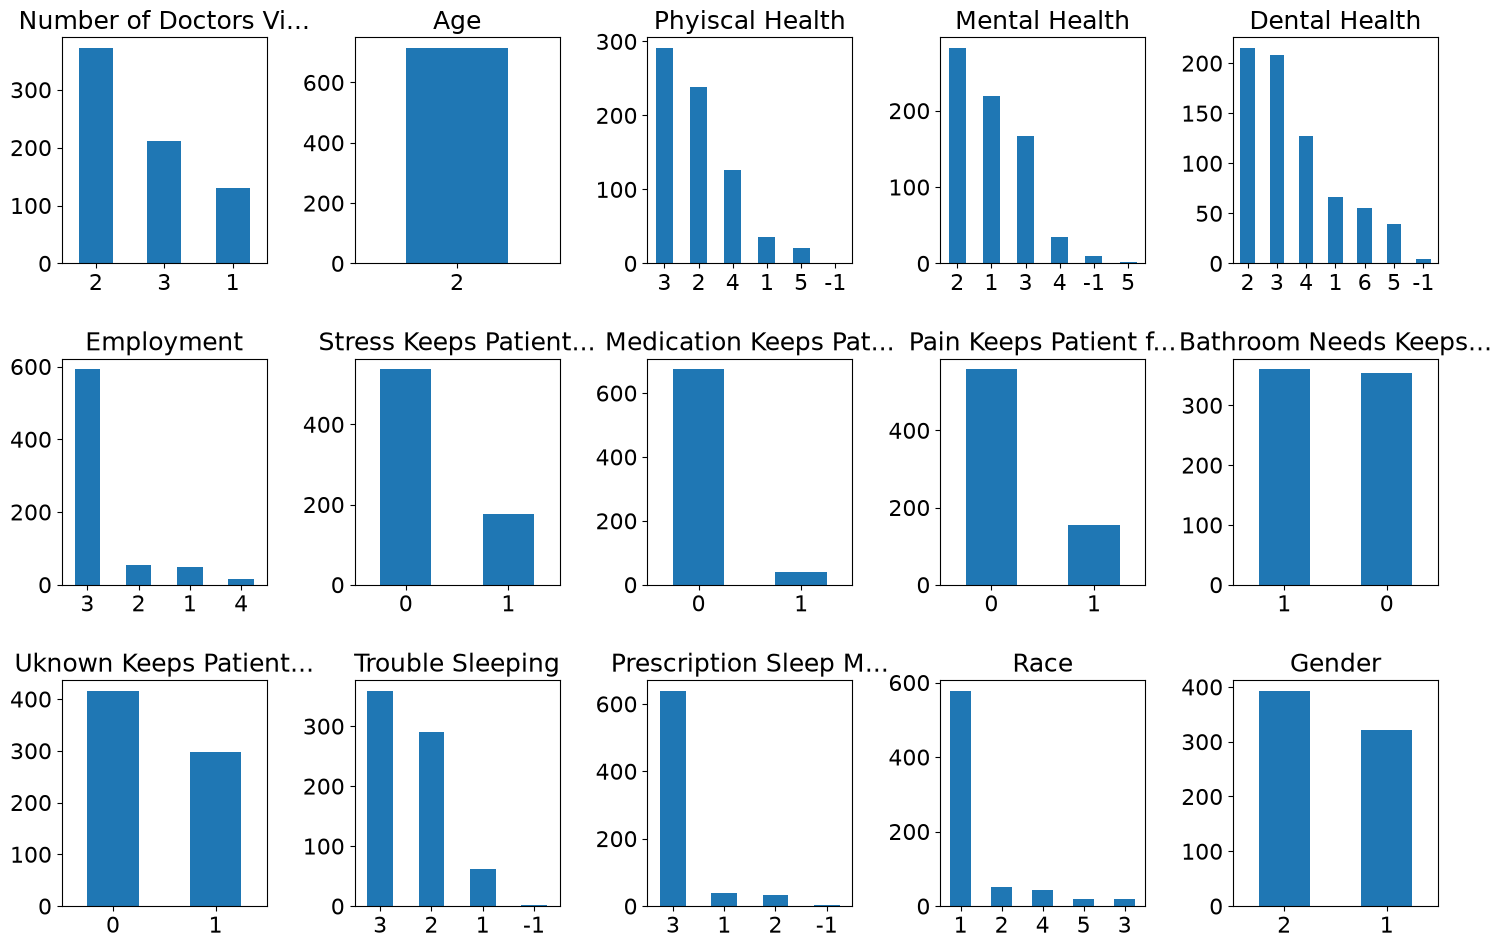

In [7]:
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.ravel()
for i, column in enumerate(df.columns):
    ax = axes[i]
    df[column].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(column[:20] + '...' if len(column) > 20 else column, fontsize=18)
    ax.tick_params(axis='x', rotation=0)
    ax.set_xlabel('')
plt.tight_layout()
plt.savefig('../images/feature_distributions.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [8]:
df['Number of Doctors Visited'].describe() # Summary statistics for the target variable

count    714.000000
mean       2.112045
std        0.683441
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        3.000000
Name: Number of Doctors Visited, dtype: float64

In [9]:
df['Age'].describe() # Summary statistics for the 'Age' column

count    714.0
mean       2.0
std        0.0
min        2.0
25%        2.0
50%        2.0
75%        2.0
max        2.0
Name: Age, dtype: float64

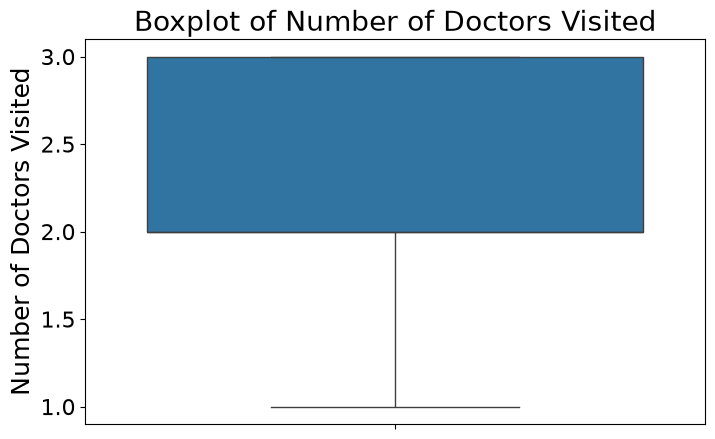

In [10]:
# Visualize the distribution of the target variable
plt.figure(figsize=(8, 5))
sns.boxplot(y='Number of Doctors Visited', data=df)
plt.title('Boxplot of Number of Doctors Visited', fontsize=20)
plt.savefig('../images/boxplot_number_of_doctors_visited.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [11]:
Q1_UP = df['Number of Doctors Visited'].quantile(0.25)
Q2_UP = df['Number of Doctors Visited'].quantile(0.5)
Q3_UP = df['Number of Doctors Visited'].quantile(0.75)

lower_limit_UP = Q1_UP - 1.5 * (Q3_UP - Q1_UP)
upper_limit_UP = Q3_UP + 1.5 * (Q3_UP - Q1_UP)

print(f"Feature: Number of Doctors Visited")
print(f"- Q1: {Q1_UP:.2f}")
print(f"- Q2 (Mediana): {Q2_UP:.2f}")
print(f"- Q3: {Q3_UP:.2f}")
print(f"- Limite Inferior: {lower_limit_UP:.2f}")
print(f"- Limite Superior: {upper_limit_UP:.2f}")

Feature: Number of Doctors Visited
- Q1: 2.00
- Q2 (Mediana): 2.00
- Q3: 3.00
- Limite Inferior: 0.50
- Limite Superior: 4.50


In [12]:
# Visualize the distribution of the target variable
class_distribution = df['Number of Doctors Visited'].value_counts()
print(class_distribution)

Number of Doctors Visited
2    372
3    211
1    131
Name: count, dtype: int64


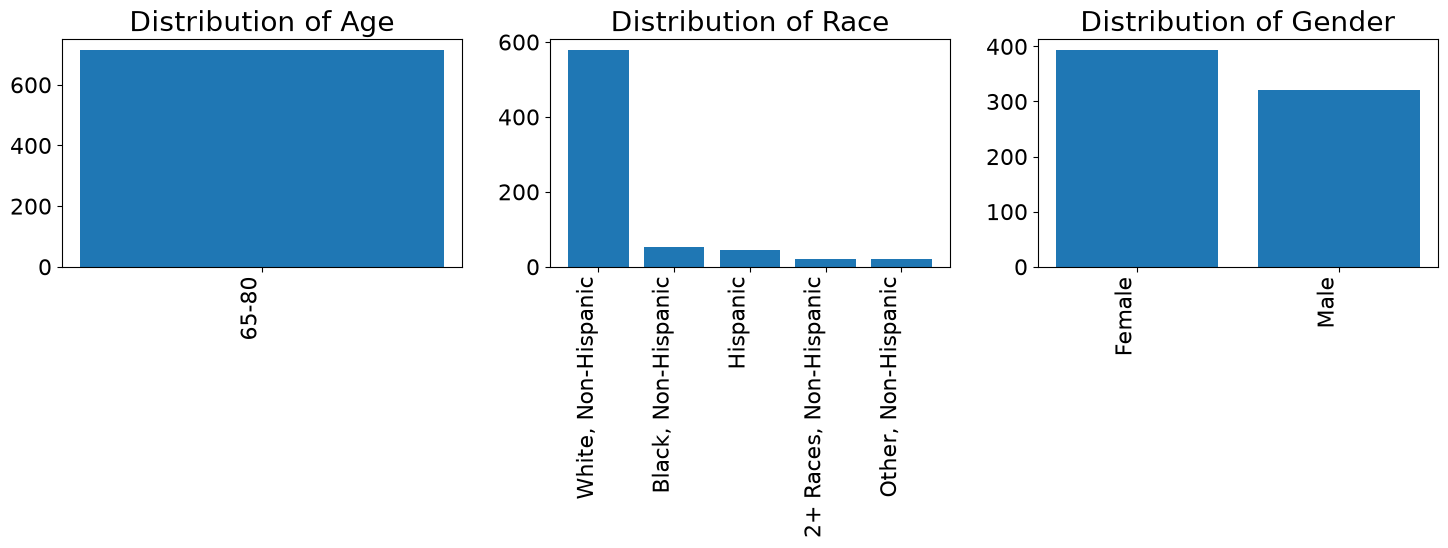

In [13]:
# Visualize the distribution of Age, Race, and Gender
df_ = df.copy()
df_["Age"] = df_["Age"].map({1: "50-64", 2: "65-80"})
df_["Race"] = df_["Race"].map({1: "White, Non-Hispanic", 2: "Black, Non-Hispanic", 3: "Other, Non-Hispanic", 4: "Hispanic", 5: "2+ Races, Non-Hispanic"})
df_["Gender"] = df_["Gender"].map({1: "Male", 2: "Female"})

plt.figure(figsize=(15, 6))
for i, col in enumerate(["Age", "Race", "Gender"]):
  plt.subplot(1, 3, i + 1)
  x = df_[col].value_counts()
  plt.bar(x.index.astype(str), x.values)
  plt.title(f"Distribution of {col}")
  plt.xticks(rotation=90, ha="right")

plt.tight_layout()
plt.savefig("../images/distribution_of_patient_age_race_gender.pdf", format="pdf", bbox_inches="tight")
plt.show()

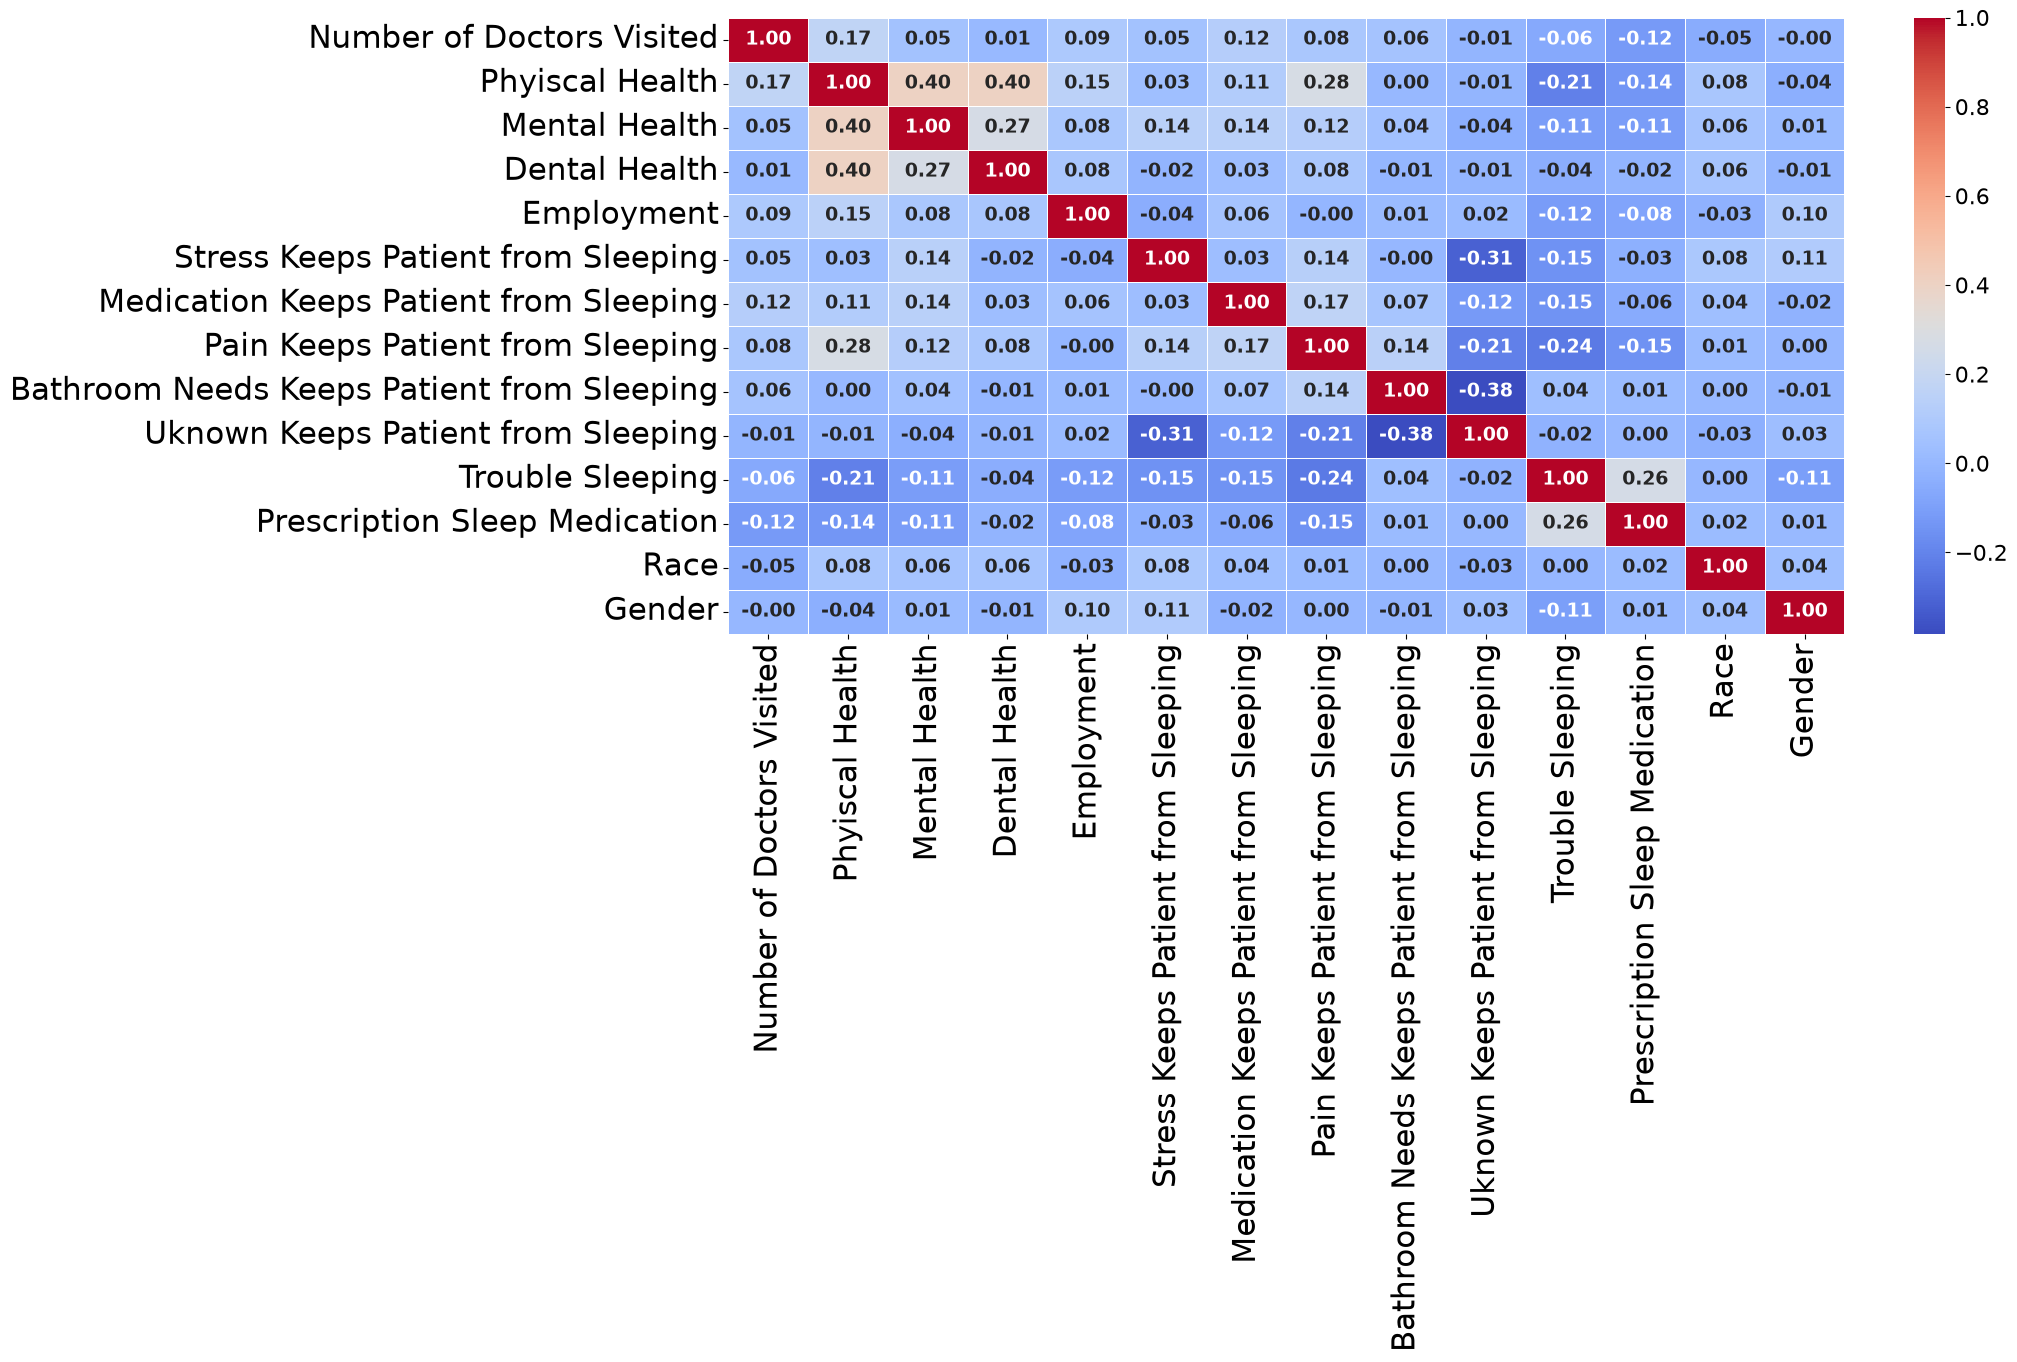

In [15]:
corr_matrix = df.drop(columns="Age").corr()
plt.figure(figsize=(18, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5, annot_kws={"size": 14, "weight": 700})
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
plt.savefig("../images/correlation_matrix.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [16]:
# Combine classes 2 and 3 into a single class (2) for the target variable
df['Number of Doctors Visited'] = df['Number of Doctors Visited'].replace(3, 2)

In [ ]:
y = df['Number of Doctors Visited'].map({1: 0, 2: 1}).to_numpy()
feature_cols = df.columns.drop('Number of Doctors Visited').tolist()
X_df = pd.get_dummies(df[feature_cols], columns=feature_cols, drop_first=False)
feature_names = X_df.columns.to_numpy()
X = X_df.values

In [18]:
X_df

,Age_2,Phyiscal Health_-1,Phyiscal Health_1,Phyiscal Health_2,Phyiscal Health_3,Phyiscal Health_4,Phyiscal Health_5,Mental Health_-1,Mental Health_1,Mental Health_2,...,Prescription Sleep Medication_1,Prescription Sleep Medication_2,Prescription Sleep Medication_3,Race_1,Race_2,Race_3,Race_4,Race_5,Gender_1,Gender_2
0,True,False,False,False,False,True,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
1,True,False,False,False,False,True,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
2,True,False,False,False,True,False,False,False,False,True,...,False,False,True,False,False,False,True,False,True,False
3,True,False,False,False,True,False,False,False,False,True,...,False,False,True,False,False,False,True,False,False,True
4,True,False,False,False,True,False,False,False,False,False,...,False,False,True,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,True,False,False,True,False,False,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
710,True,False,False,True,False,False,False,False,False,True,...,False,False,True,True,False,False,False,False,False,True
711,True,False,False,False,False,True,False,False,False,True,...,False,False,True,True,False,False,False,False,True,False
712,True,False,False,False,True,False,False,False,True,False,...,False,False,True,True,False,False,False,False,False,True


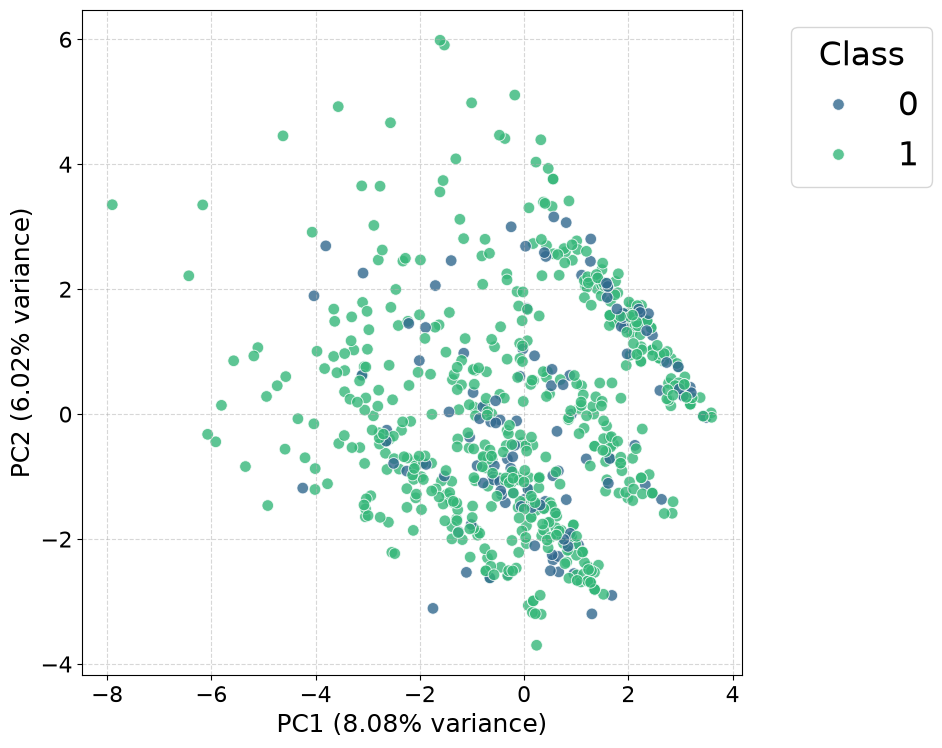

In [19]:
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X)
pca2 = PCA(n_components=2)
pcs2 = pca2.fit_transform(X_scaled_pca)
df_pca2 = pd.DataFrame(pcs2, columns=['PC1', 'PC2'])
df_pca2['target'] = y
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='target', palette='viridis', data=df_pca2, alpha=0.8, s=70)
e1, e2 = pca2.explained_variance_ratio_[:2] * 100
plt.xlabel(f'PC1 ({e1:.2f}% variance)')
plt.ylabel(f'PC2 ({e2:.2f}% variance)')
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../images/pca_2d.pdf', format='pdf', bbox_inches='tight')
plt.show()

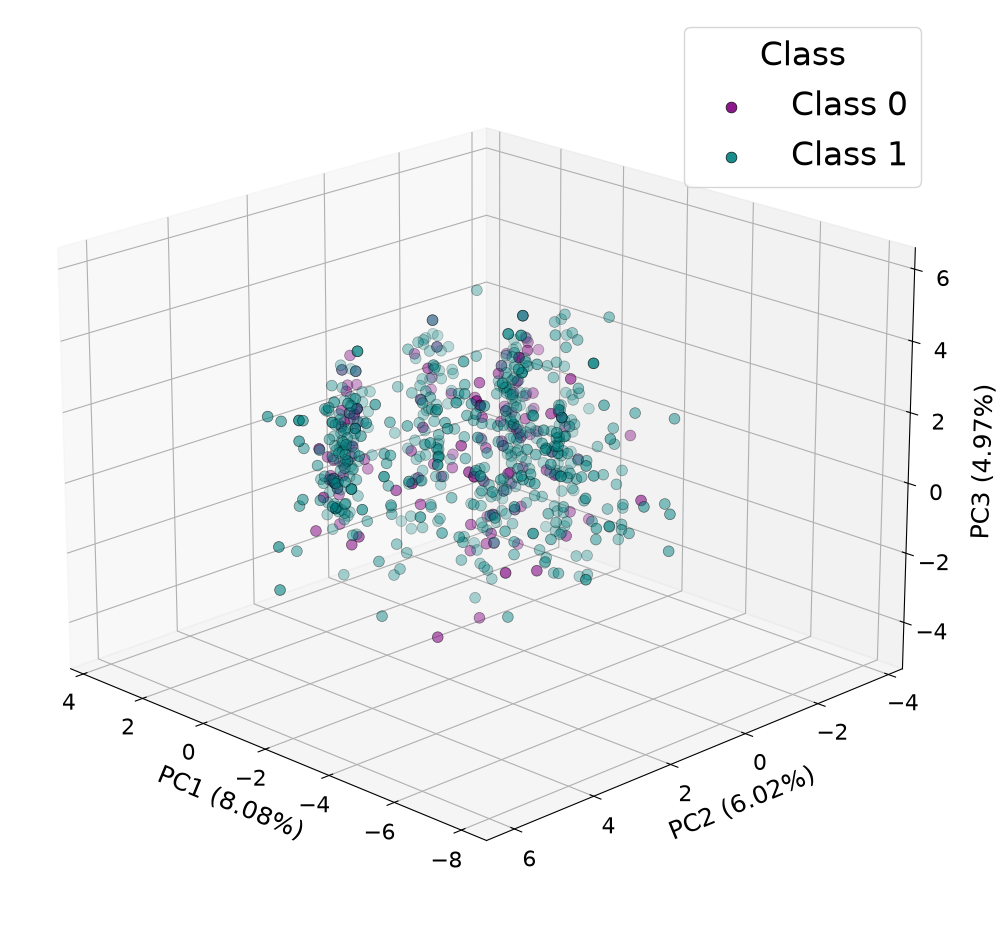

In [20]:
pca3 = PCA(n_components=3)
pcs3 = pca3.fit_transform(X_scaled_pca)
df_pca3 = pd.DataFrame(pcs3, columns=['PC1', 'PC2', 'PC3'])
df_pca3['target'] = y
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
colors = ['purple', 'teal', 'gold']
for cls, color in zip(sorted(df_pca3['target'].unique()), colors):
    subset = df_pca3[df_pca3['target'] == cls]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'], color=color, label=f'Class {cls}', s=60, alpha=0.9, edgecolor='black', linewidth=0.5)
e1, e2, e3 = pca3.explained_variance_ratio_[:3] * 100
ax.set_xlabel(f'PC1 ({e1:.2f}%)', labelpad=10)
ax.set_ylabel(f'PC2 ({e2:.2f}%)', labelpad=10)
ax.set_zlabel(f'PC3 ({e3:.2f}%)', labelpad=10)
plt.legend(title='Class', loc='best')
ax.view_init(elev=20, azim=135)
plt.tight_layout()
plt.savefig('../images/pca_3d.pdf', format='pdf', bbox_inches='tight')
plt.show()